## Import Libraries

In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from IPython.display import display, Markdown

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    IsolationForest
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)
from sklearn.inspection import permutation_importance

import xgboost as xgb
from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("creditcard.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("All libraries imported successfully.")
print("LightGBM available:", LIGHTGBM_AVAILABLE)

All libraries imported successfully.
LightGBM available: True


## LOAD DATASET

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "creditcard.csv not found. Upload creditcard.csv into the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## VALIDATE DATASET STRUCTURE

In [3]:
expected_columns = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]

missing_cols = [col for col in expected_columns if col not in df.columns]
extra_cols = [col for col in df.columns if col not in expected_columns]

if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

df = df[expected_columns].copy()

print("Dataset columns validated.")
print("Extra columns ignored:", extra_cols if extra_cols else "None")
print("Final column count:", len(df.columns))

Dataset columns validated.
Extra columns ignored: None
Final column count: 31


## DATA QUALITY OVERVIEW

In [4]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

display(quality_report)

print("\nDuplicate rows:", df.duplicated().sum())
print("\nBasic statistics:")
display(df.describe().T)

,Column,Data Type,Missing Values,Unique Values
0,Time,float64,0,124592
1,V1,float64,0,275663
2,V2,float64,0,275663
3,V3,float64,0,275663
4,V4,float64,0,275663
5,V5,float64,0,275663
6,V6,float64,0,275663
7,V7,float64,0,275663
8,V8,float64,0,275663
9,V9,float64,0,275663



Duplicate rows: 1081

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## CLASS DISTRIBUTION

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%
Legitimate-to-fraud ratio: 577.88:1


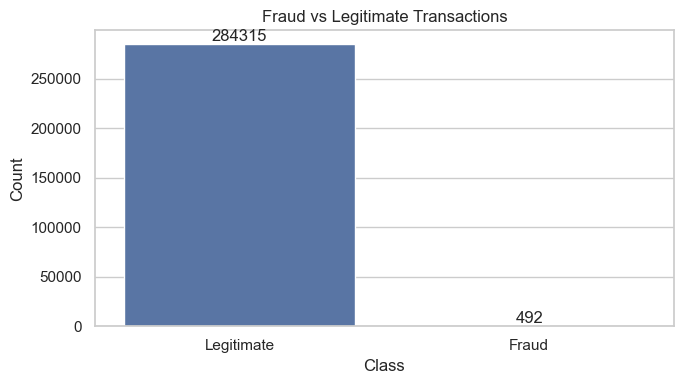

In [5]:
class_counts = df["Class"].value_counts().sort_index()
fraud_rate = df["Class"].mean()
imbalance_ratio = class_counts[0] / class_counts[1]

print("Class distribution:")
print(class_counts)

print(f"\nFraud rate: {fraud_rate:.4%}")
print(f"Legitimate-to-fraud ratio: {imbalance_ratio:.2f}:1")

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x="Class")
ax.set_title("Fraud vs Legitimate Transactions")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_xticklabels(["Legitimate", "Fraud"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## CLASS DISTRIBUTION ON LOG SCALE

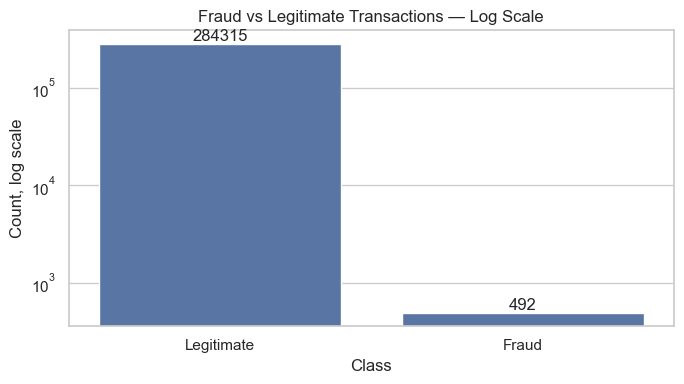

In [6]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x="Class")
ax.set_yscale("log")
ax.set_title("Fraud vs Legitimate Transactions — Log Scale")
ax.set_xlabel("Class")
ax.set_ylabel("Count, log scale")
ax.set_xticklabels(["Legitimate", "Fraud"])

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## TRANSACTION AMOUNT DISTRIBUTION

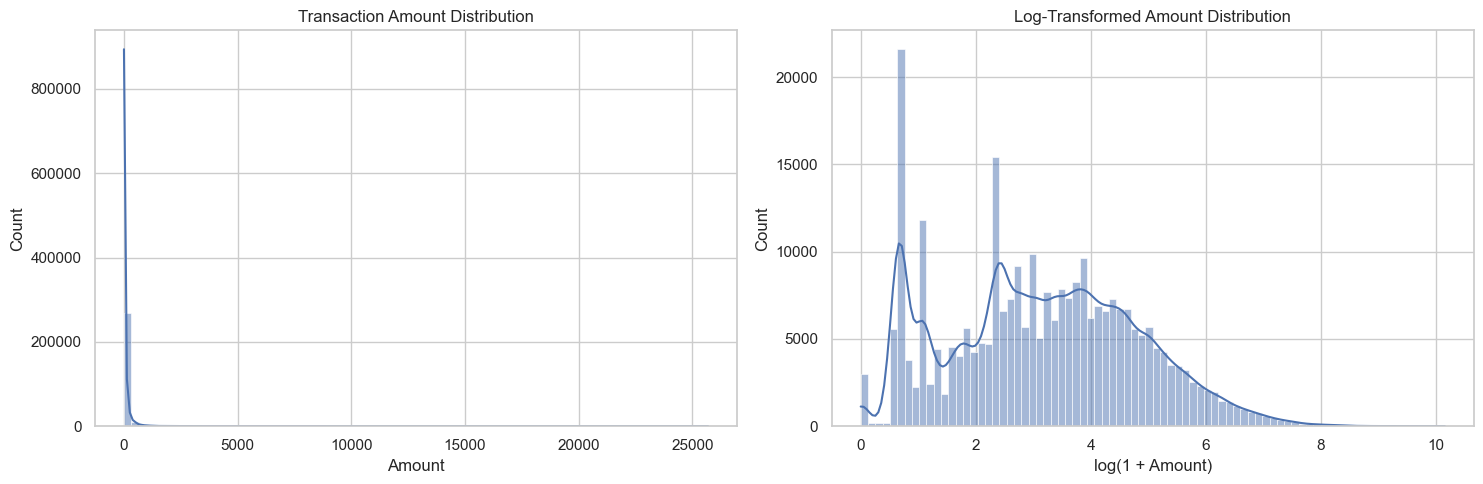

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["Amount"], bins=80, kde=True, ax=axes[0])
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount")

sns.histplot(np.log1p(df["Amount"]), bins=80, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Amount Distribution")
axes[1].set_xlabel("log(1 + Amount)")

plt.tight_layout()
plt.show()

display(df["Amount"].describe())

## AMOUNT DISTRIBUTION BY CLASS

amount_summary = df.groupby("Class")["Amount"].describe()
display(amount_summary)

df_plot = df.copy()
df_plot["LogAmount"] = np.log1p(df_plot["Amount"])

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_plot, x="Class", y="LogAmount")
plt.title("Transaction Amount by Class — Log Scale")
plt.xlabel("Class")
plt.ylabel("log(1 + Amount)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.tight_layout()
plt.show()

## TIME DISTRIBUTION

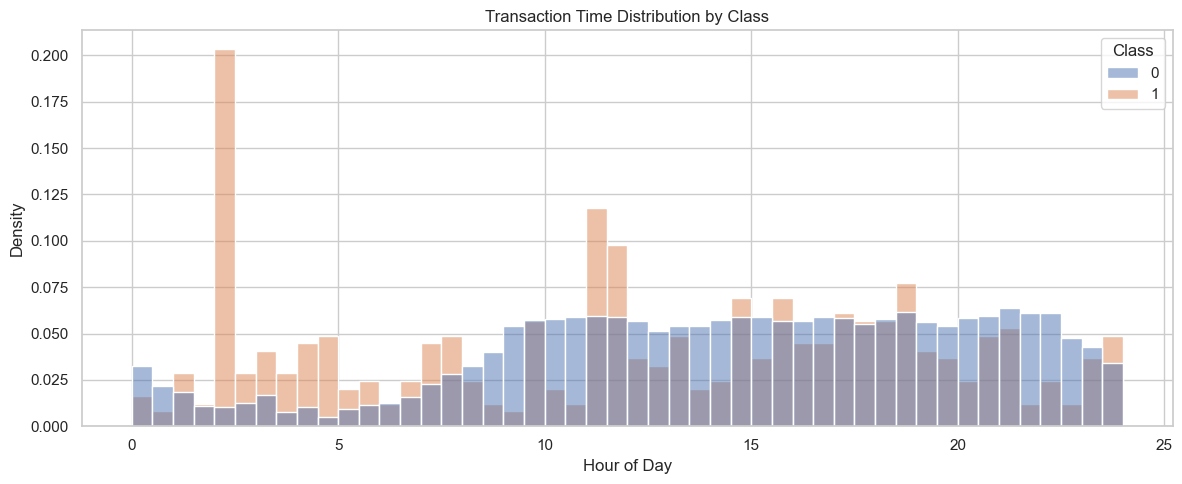

In [8]:
df_time = df.copy()
df_time["Hour"] = (df_time["Time"] / 3600) % 24

plt.figure(figsize=(12, 5))
sns.histplot(
    data=df_time,
    x="Hour",
    hue="Class",
    bins=48,
    stat="density",
    common_norm=False
)
plt.title("Transaction Time Distribution by Class")
plt.xlabel("Hour of Day")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## FRAUD RATE OVER TIME

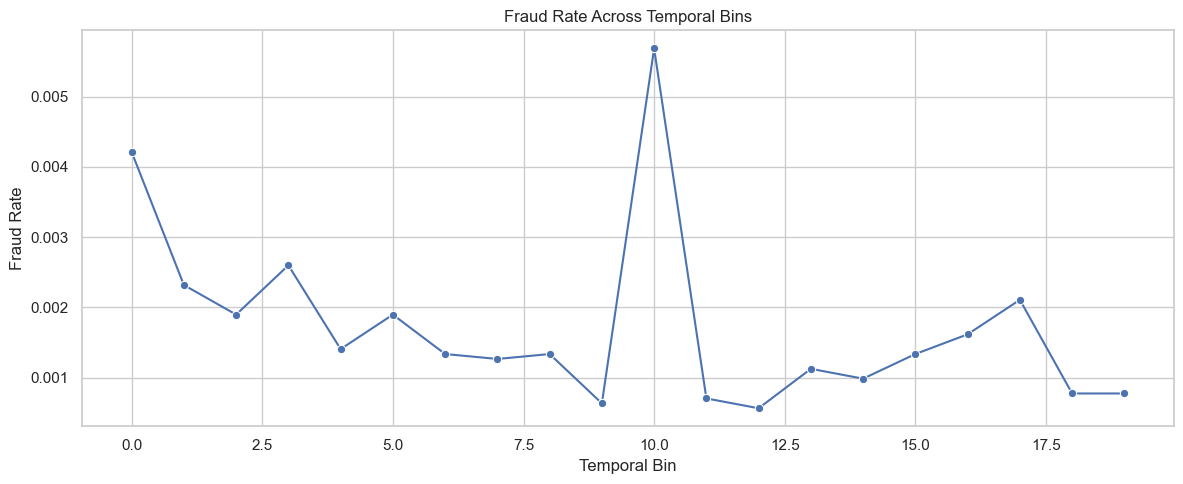

,Time_Bin,Class,Time_Bin_Index
0,"(-0.001, 25297.6]",0.004213,0
1,"(25297.6, 35027.0]",0.002317,1
2,"(35027.0, 41216.9]",0.001896,2
3,"(41216.9, 47694.2]",0.002598,3
4,"(47694.2, 54201.5]",0.001404,4


In [9]:
df_time_window = df.copy()
df_time_window["Time_Bin"] = pd.qcut(df_time_window["Time"], q=20, duplicates="drop")

fraud_over_time = df_time_window.groupby("Time_Bin")["Class"].mean().reset_index()
fraud_over_time["Time_Bin_Index"] = range(len(fraud_over_time))

plt.figure(figsize=(12, 5))
sns.lineplot(data=fraud_over_time, x="Time_Bin_Index", y="Class", marker="o")
plt.title("Fraud Rate Across Temporal Bins")
plt.xlabel("Temporal Bin")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

display(fraud_over_time.head())

## FEATURE CORRELATION WITH TARGET

,Correlation with Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


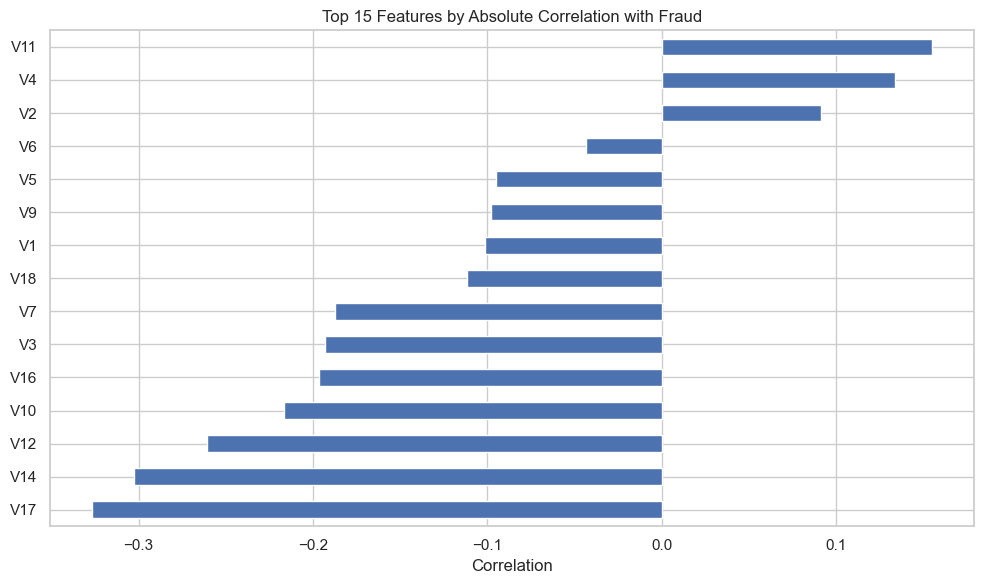

In [10]:
target_corr = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(target_corr.to_frame("Correlation with Class").head(15))

plt.figure(figsize=(10, 6))
target_corr.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features by Absolute Correlation with Fraud")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

## CORRELATION HEATMAP

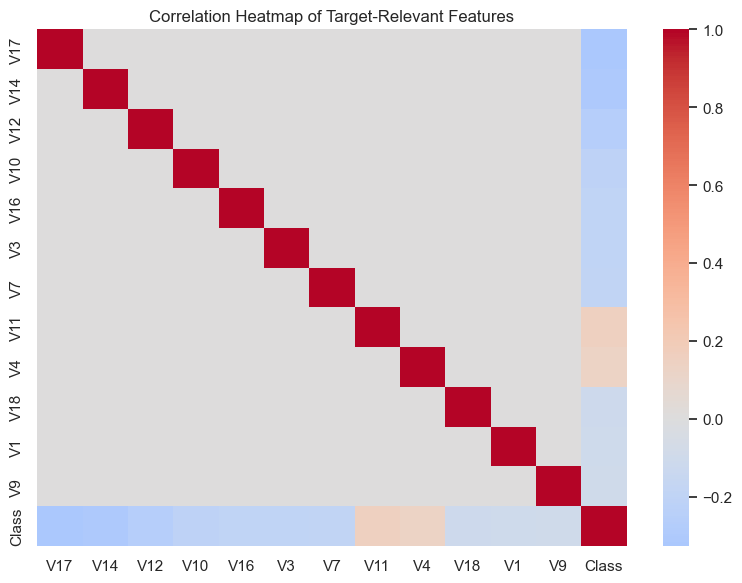

In [11]:
top_corr_features = target_corr.head(12).index.tolist() + ["Class"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[top_corr_features].corr(),
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Correlation Heatmap of Target-Relevant Features")
plt.tight_layout()
plt.show()

## FRAUD VS LEGITIMATE FEATURE DISTRIBUTIONS

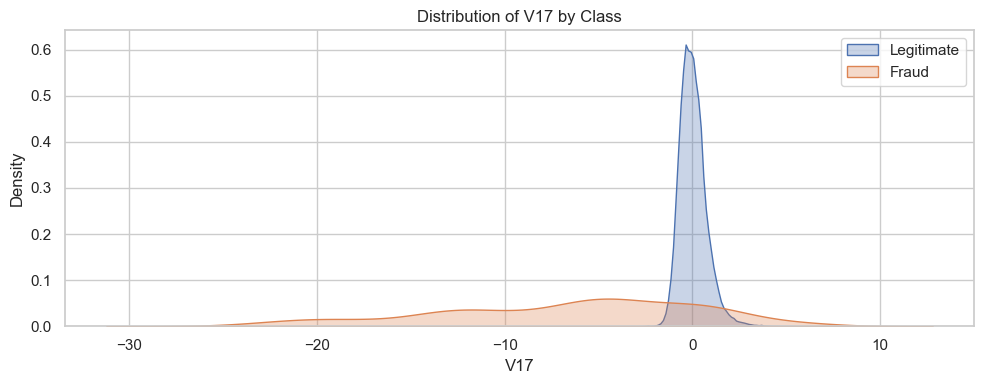

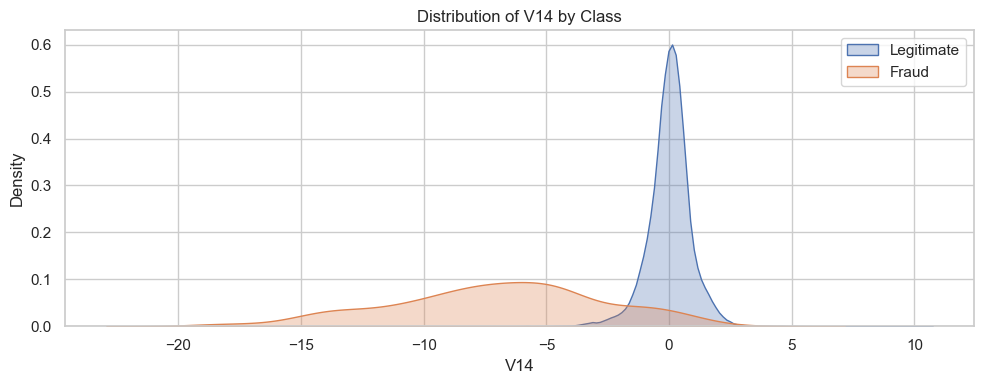

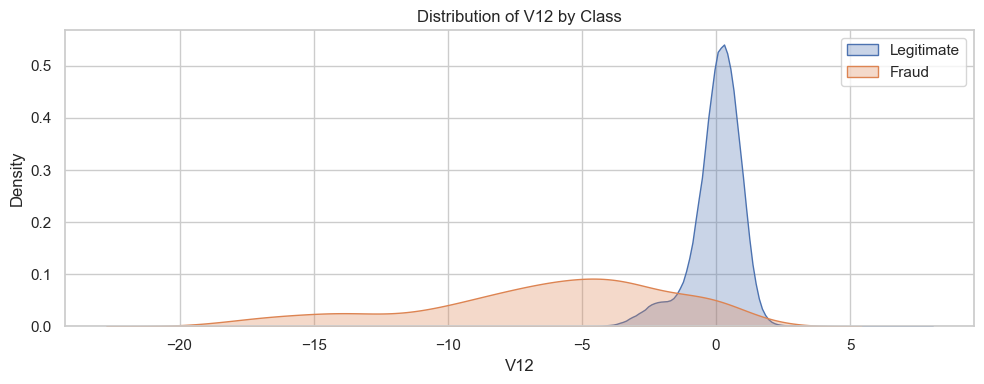

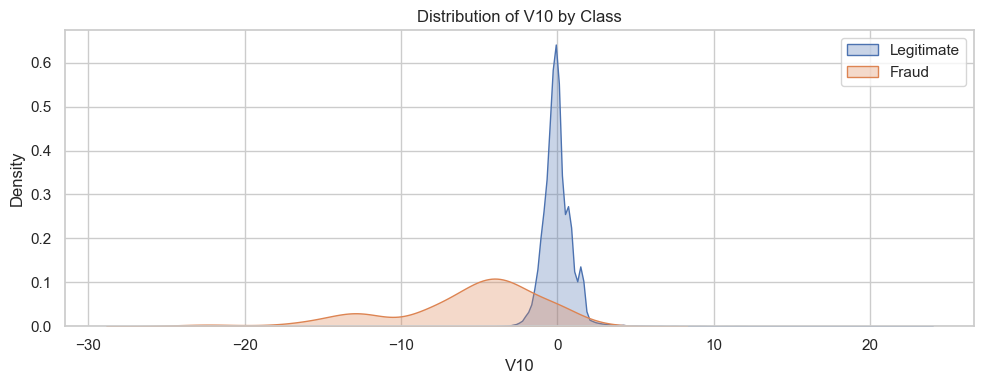

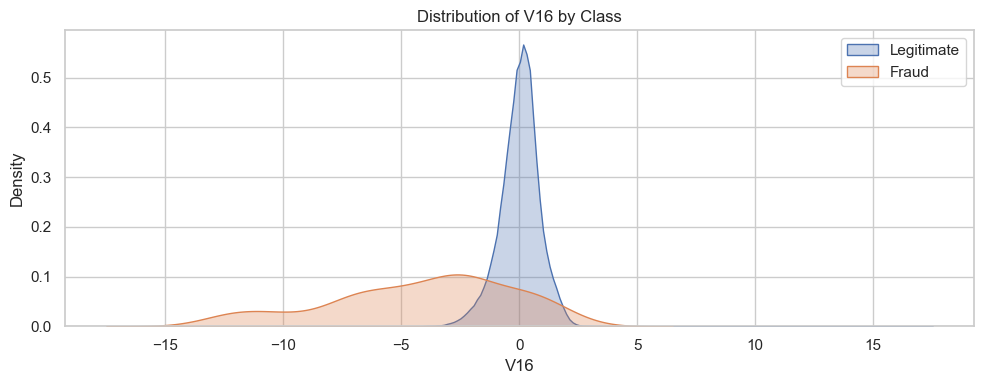

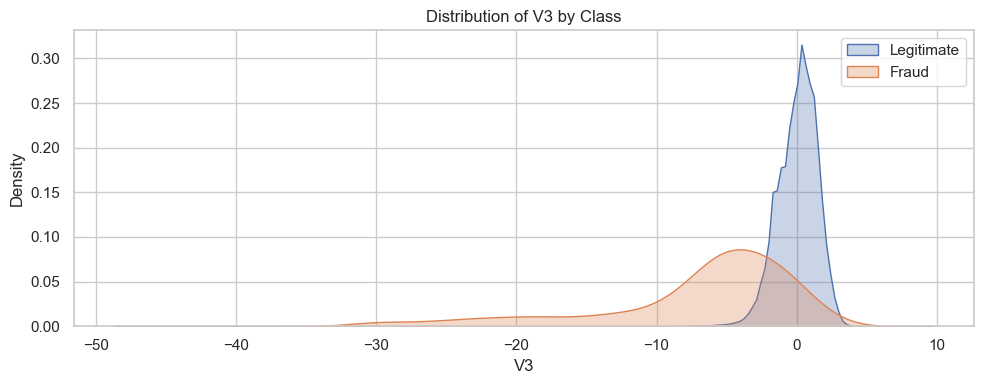

In [12]:
top_features = target_corr.head(6).index.tolist()

for feature in top_features:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df[df["Class"] == 0], x=feature, label="Legitimate", fill=True, alpha=0.3)
    sns.kdeplot(data=df[df["Class"] == 1], x=feature, label="Fraud", fill=True, alpha=0.3)
    plt.title(f"Distribution of {feature} by Class")
    plt.legend()
    plt.tight_layout()
    plt.show()

## TEMPORAL TRAIN/VALIDATION/TEST SPLIT

In [13]:
n = len(df)

train_end = int(0.70 * n)
valid_end = int(0.80 * n)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

X_train = train_df.drop("Class", axis=1)
y_train = train_df["Class"]

X_valid = valid_df.drop("Class", axis=1)
y_valid = valid_df["Class"]

X_test = test_df.drop("Class", axis=1)
y_test = test_df["Class"]

print("Training set:", X_train.shape, "| Frauds:", int(y_train.sum()))
print("Validation set:", X_valid.shape, "| Frauds:", int(y_valid.sum()))
print("Test set:", X_test.shape, "| Frauds:", int(y_test.sum()))

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

print(f"\nTraining fraud rate: {y_train.mean():.4%}")
print(f"Validation fraud rate: {y_valid.mean():.4%}")
print(f"Test fraud rate: {y_test.mean():.4%}")
print(f"scale_pos_weight for boosting models: {scale_pos_weight:.2f}")

Training set: (199364, 30) | Frauds: 384
Validation set: (28481, 30) | Frauds: 33
Test set: (56962, 30) | Frauds: 75

Training fraud rate: 0.1926%
Validation fraud rate: 0.1159%
Test fraud rate: 0.1317%
scale_pos_weight for boosting models: 518.18


## EVALUATION FUNCTIONS

In [14]:
def find_best_threshold(y_true, scores, metric="f1"):
    """
    Finds the best classification threshold on validation data.
    Default: maximize F1-score.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    if len(thresholds) == 0:
        return 0.5

    precision = precision[:-1]
    recall = recall[:-1]

    f1_scores = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    if metric == "f1":
        best_idx = np.nanargmax(f1_scores)
    elif metric == "recall":
        best_idx = np.nanargmax(recall)
    else:
        raise ValueError("metric must be 'f1' or 'recall'")

    return thresholds[best_idx]


def evaluate_model(y_true, scores, threshold):
    """
    Computes performance metrics for fraud detection.
    """
    preds = (scores >= threshold).astype(int)

    metrics = {
        "ROC_AUC": roc_auc_score(y_true, scores),
        "PR_AUC": average_precision_score(y_true, scores),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, preds),
        "Threshold": threshold
    }

    return metrics


def get_model_scores(model, X, model_name):
    """
    Returns fraud score where higher value means more suspicious.
    """
    if model_name == "Isolation Forest":
        return -model.decision_function(X)

    return model.predict_proba(X)[:, 1]


def plot_confusion_matrix(y_true, scores, threshold, model_name):
    """
    Plots confusion matrix for a model.
    """
    preds = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Legitimate", "Predicted Fraud"],
        yticklabels=["Actual Legitimate", "Actual Fraud"]
    )
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true,
        preds,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    ))

## DEFINE COMPARATIVE MODELS

In [15]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Isolation Forest": IsolationForest(
        n_estimators=250,
        contamination=float(y_train.mean()),
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=250,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

print("Models prepared:")
for model_name in models:
    print("-", model_name)

Models prepared:
- Logistic Regression
- Random Forest
- Extra Trees
- Isolation Forest
- XGBoost
- LightGBM


## TRAIN AND EVALUATE ALL MODELS

In [16]:
fitted_models = {}
model_scores = {}
model_thresholds = {}
results = []

for model_name, model in models.items():
    print("=" * 90)
    print(f"Training model: {model_name}")

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    valid_scores = get_model_scores(model, X_valid, model_name)
    test_scores = get_model_scores(model, X_test, model_name)

    threshold = find_best_threshold(y_valid, valid_scores, metric="f1")

    valid_metrics = evaluate_model(y_valid, valid_scores, threshold)
    test_metrics = evaluate_model(y_test, test_scores, threshold)

    fitted_models[model_name] = model
    model_scores[model_name] = {
        "valid_scores": valid_scores,
        "test_scores": test_scores
    }
    model_thresholds[model_name] = threshold

    results.append({
        "Model": model_name,
        "Train_Time_Seconds": train_time,
        "Validation_ROC_AUC": valid_metrics["ROC_AUC"],
        "Validation_PR_AUC": valid_metrics["PR_AUC"],
        "Validation_F1": valid_metrics["F1"],
        "Test_ROC_AUC": test_metrics["ROC_AUC"],
        "Test_PR_AUC": test_metrics["PR_AUC"],
        "Test_Precision": test_metrics["Precision"],
        "Test_Recall": test_metrics["Recall"],
        "Test_F1": test_metrics["F1"],
        "Test_Balanced_Accuracy": test_metrics["Balanced_Accuracy"],
        "Selected_Threshold": threshold
    })

    print(f"Training time: {train_time:.2f} seconds")
    print(f"Validation ROC-AUC: {valid_metrics['ROC_AUC']:.4f}")
    print(f"Validation PR-AUC:  {valid_metrics['PR_AUC']:.4f}")
    print(f"Validation F1:      {valid_metrics['F1']:.4f}")
    print(f"Selected threshold: {threshold:.6f}")
    print(f"Test ROC-AUC:       {test_metrics['ROC_AUC']:.4f}")
    print(f"Test PR-AUC:        {test_metrics['PR_AUC']:.4f}")
    print(f"Test Precision:     {test_metrics['Precision']:.4f}")
    print(f"Test Recall:        {test_metrics['Recall']:.4f}")
    print(f"Test F1:            {test_metrics['F1']:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Validation_PR_AUC", ascending=False).reset_index(drop=True)

display(results_df)

Training model: Logistic Regression
Training time: 1.17 seconds
Validation ROC-AUC: 0.9706
Validation PR-AUC:  0.8308
Validation F1:      0.8667
Selected threshold: 0.999997
Test ROC-AUC:       0.9833
Test PR-AUC:        0.7456
Test Precision:     0.9231
Test Recall:        0.6400
Test F1:            0.7559
Training model: Random Forest
Training time: 75.93 seconds
Validation ROC-AUC: 0.9350
Validation PR-AUC:  0.8397
Validation F1:      0.8814
Selected threshold: 0.344874
Test ROC-AUC:       0.9494
Test PR-AUC:        0.8136
Test Precision:     0.9344
Test Recall:        0.7600
Test F1:            0.8382
Training model: Extra Trees
Training time: 16.40 seconds
Validation ROC-AUC: 0.9483
Validation PR-AUC:  0.8378
Validation F1:      0.8814
Selected threshold: 0.334718
Test ROC-AUC:       0.9619
Test PR-AUC:        0.8209
Test Precision:     0.8750
Test Recall:        0.7467
Test F1:            0.8058
Training model: Isolation Forest
Training time: 5.77 seconds
Validation ROC-AUC: 0.92

,Model,Train_Time_Seconds,Validation_ROC_AUC,Validation_PR_AUC,Validation_F1,Test_ROC_AUC,Test_PR_AUC,Test_Precision,Test_Recall,Test_F1,Test_Balanced_Accuracy,Selected_Threshold
0,XGBoost,4.971137,0.976872,0.840053,0.881356,0.987164,0.794157,0.861538,0.746667,0.800000,0.873254,0.742759
1,Random Forest,75.927862,0.934984,0.839737,0.881356,0.949398,0.813565,0.934426,0.760000,0.838235,0.879965,0.344874
2,Extra Trees,16.401501,0.948312,0.837820,0.881356,0.961947,0.820876,0.875000,0.746667,0.805755,0.873263,0.334718
3,Logistic Regression,1.170661,0.970591,0.830829,0.866667,0.983313,0.745602,0.923077,0.640000,0.755906,0.819965,0.999997
4,Isolation Forest,5.766363,0.922851,0.036948,0.104294,0.944251,0.040759,0.066667,0.333333,0.111111,0.663590,-0.063853
5,LightGBM,2.606052,0.708586,0.006969,0.027051,0.633926,0.004087,0.010351,0.306667,0.020026,0.634006,1.000000


## COMPARATIVE RESULTS TABLE

In [17]:
summary_cols = [
    "Model",
    "Validation_PR_AUC",
    "Test_ROC_AUC",
    "Test_PR_AUC",
    "Test_Precision",
    "Test_Recall",
    "Test_F1",
    "Test_Balanced_Accuracy",
    "Train_Time_Seconds",
    "Selected_Threshold"
]

comparison_table = results_df[summary_cols].copy()

numeric_cols = comparison_table.columns.drop("Model")
comparison_table[numeric_cols] = comparison_table[numeric_cols].round(4)

display(comparison_table)

comparison_table.to_csv(OUTPUT_DIR / "model_comparison_results.csv", index=False)
print("Saved: outputs/model_comparison_results.csv")

,Model,Validation_PR_AUC,Test_ROC_AUC,Test_PR_AUC,Test_Precision,Test_Recall,Test_F1,Test_Balanced_Accuracy,Train_Time_Seconds,Selected_Threshold
0,XGBoost,0.8401,0.9872,0.7942,0.8615,0.7467,0.8000,0.8733,4.9711,0.7428
1,Random Forest,0.8397,0.9494,0.8136,0.9344,0.7600,0.8382,0.8800,75.9279,0.3449
2,Extra Trees,0.8378,0.9619,0.8209,0.8750,0.7467,0.8058,0.8733,16.4015,0.3347
3,Logistic Regression,0.8308,0.9833,0.7456,0.9231,0.6400,0.7559,0.8200,1.1707,1.0000
4,Isolation Forest,0.0369,0.9443,0.0408,0.0667,0.3333,0.1111,0.6636,5.7664,-0.0639
5,LightGBM,0.0070,0.6339,0.0041,0.0104,0.3067,0.0200,0.6340,2.6061,1.0000


Saved: outputs/model_comparison_results.csv


## PERFORMANCE COMPARISON BAR CHART

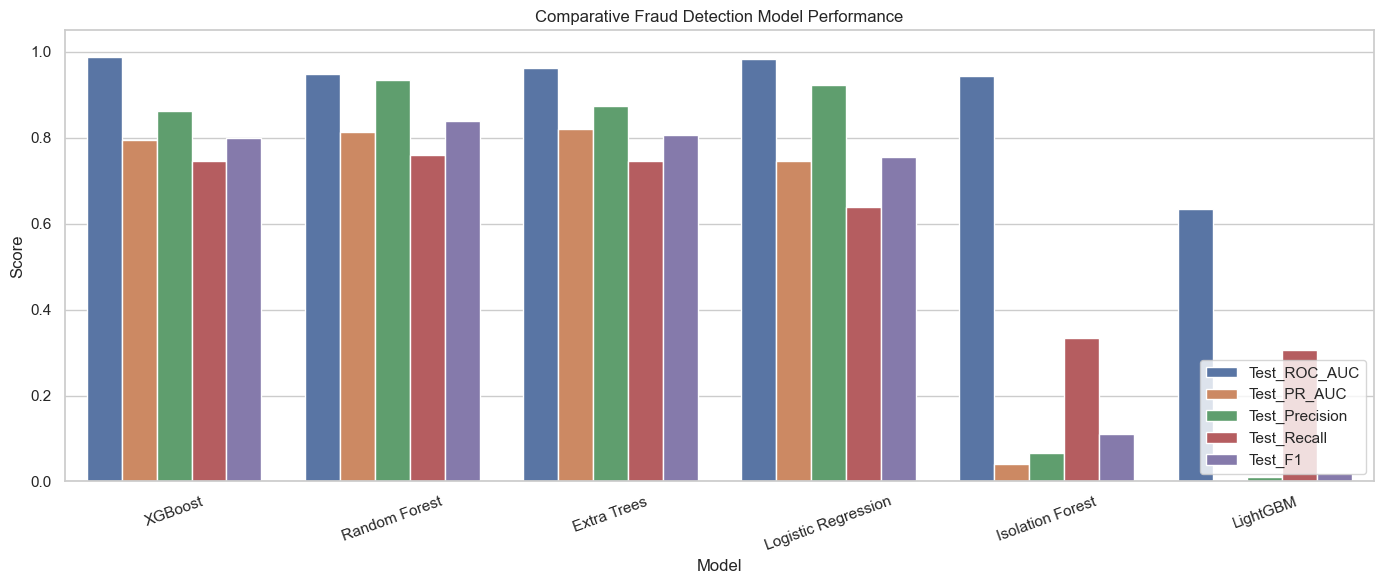

In [18]:
plot_df = comparison_table.melt(
    id_vars="Model",
    value_vars=["Test_ROC_AUC", "Test_PR_AUC", "Test_Precision", "Test_Recall", "Test_F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Comparative Fraud Detection Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## ROC CURVES

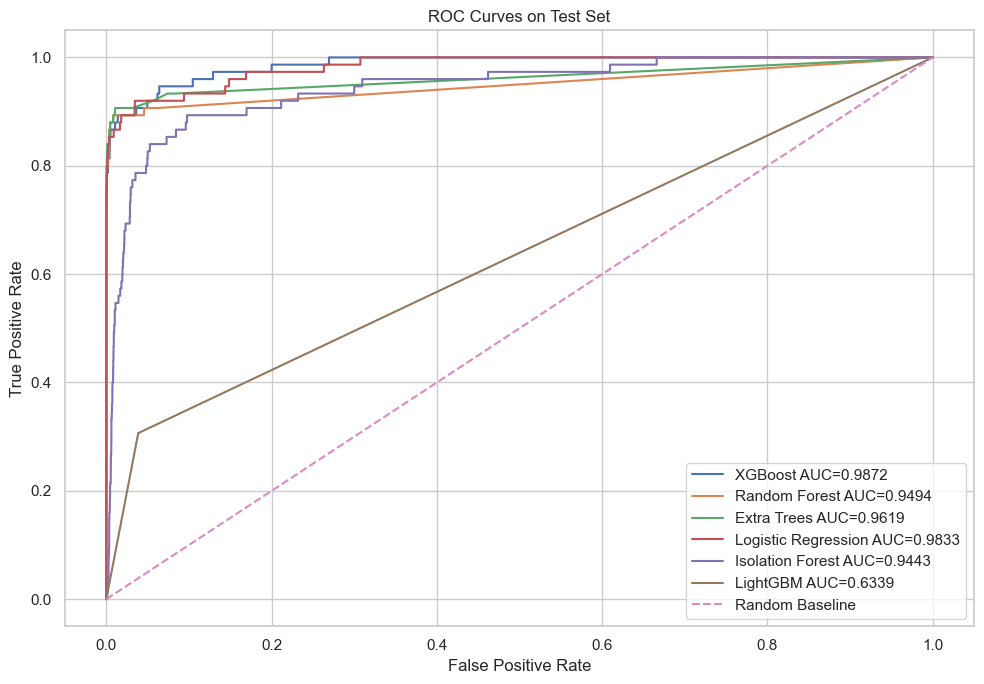

In [19]:
plt.figure(figsize=(10, 7))

for model_name in comparison_table["Model"]:
    scores = model_scores[model_name]["test_scores"]
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_value = roc_auc_score(y_test, scores)

    plt.plot(fpr, tpr, label=f"{model_name} AUC={auc_value:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Baseline")
plt.title("ROC Curves on Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## PRECISION-RECALL CURVES

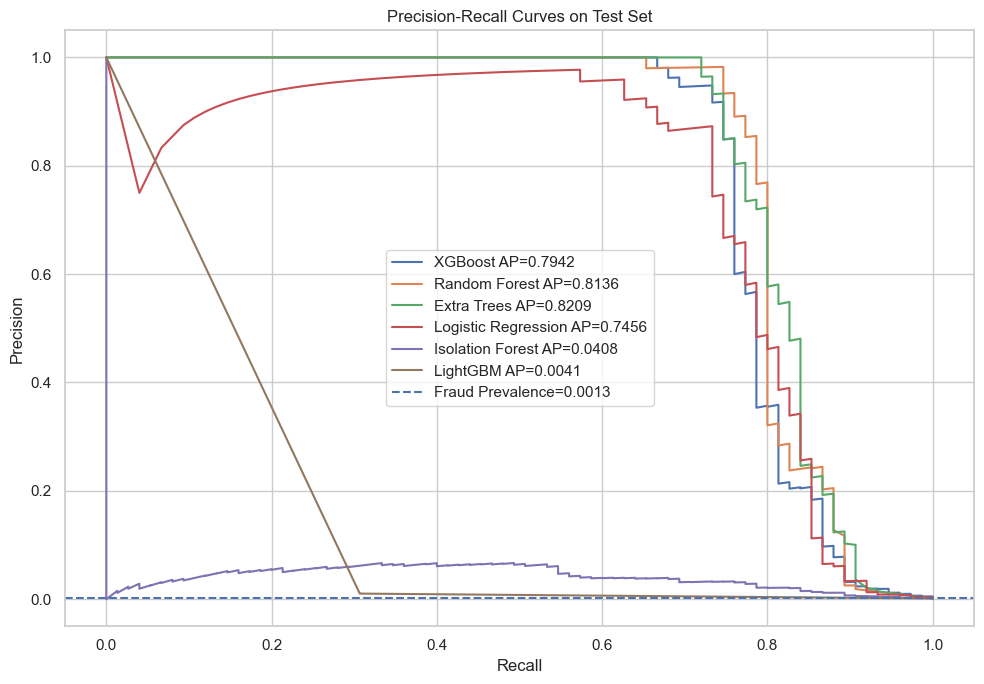

In [20]:
plt.figure(figsize=(10, 7))

for model_name in comparison_table["Model"]:
    scores = model_scores[model_name]["test_scores"]
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ap_value = average_precision_score(y_test, scores)

    plt.plot(recall, precision, label=f"{model_name} AP={ap_value:.4f}")

baseline = y_test.mean()
plt.axhline(baseline, linestyle="--", label=f"Fraud Prevalence={baseline:.4f}")

plt.title("Precision-Recall Curves on Test Set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## CONFUSION MATRICES FOR ALL MODELS

Confusion Matrix and Classification Report: XGBoost


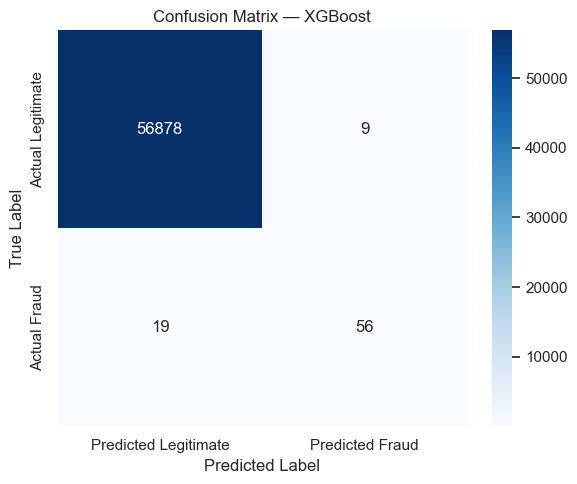

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56887
       Fraud       0.86      0.75      0.80        75

    accuracy                           1.00     56962
   macro avg       0.93      0.87      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix and Classification Report: Random Forest


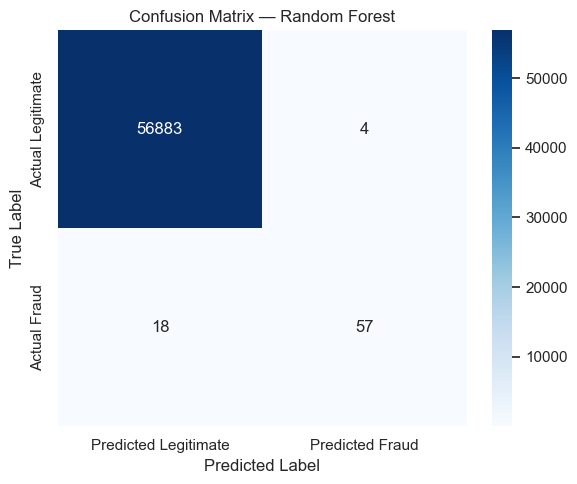

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56887
       Fraud       0.93      0.76      0.84        75

    accuracy                           1.00     56962
   macro avg       0.97      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix and Classification Report: Extra Trees


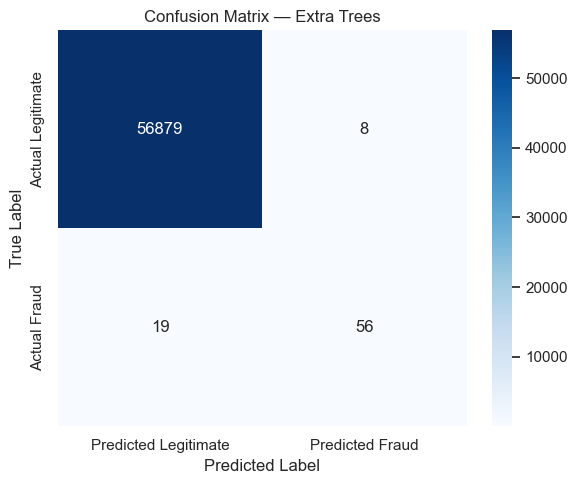

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56887
       Fraud       0.88      0.75      0.81        75

    accuracy                           1.00     56962
   macro avg       0.94      0.87      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix and Classification Report: Logistic Regression


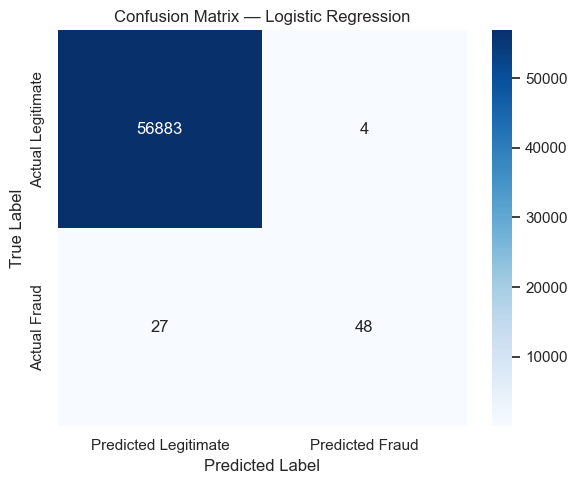

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56887
       Fraud       0.92      0.64      0.76        75

    accuracy                           1.00     56962
   macro avg       0.96      0.82      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix and Classification Report: Isolation Forest


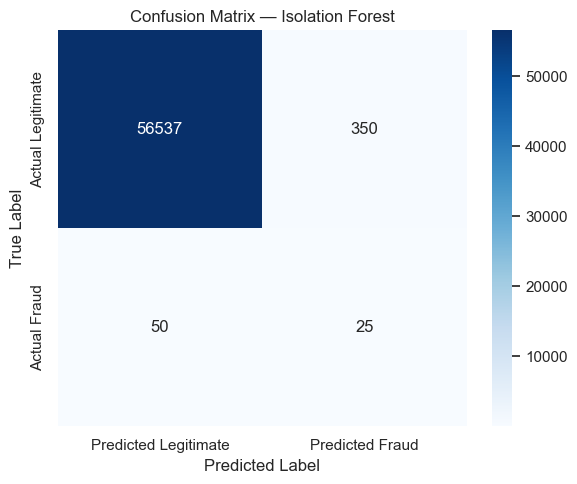

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     56887
       Fraud       0.07      0.33      0.11        75

    accuracy                           0.99     56962
   macro avg       0.53      0.66      0.55     56962
weighted avg       1.00      0.99      1.00     56962

Confusion Matrix and Classification Report: LightGBM


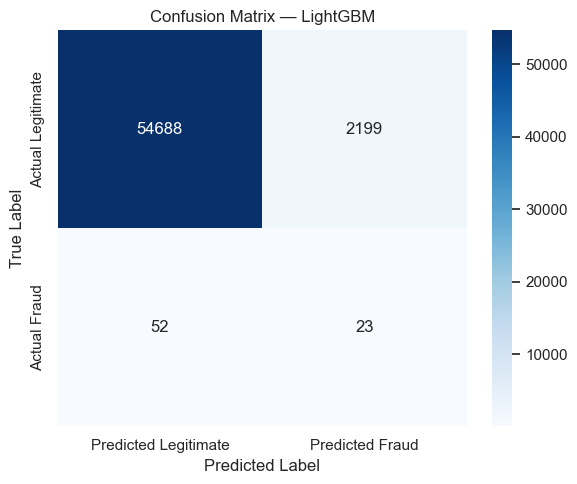

              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56887
       Fraud       0.01      0.31      0.02        75

    accuracy                           0.96     56962
   macro avg       0.50      0.63      0.50     56962
weighted avg       1.00      0.96      0.98     56962



In [21]:
for model_name in comparison_table["Model"]:
    print("=" * 90)
    print(f"Confusion Matrix and Classification Report: {model_name}")

    scores = model_scores[model_name]["test_scores"]
    threshold = model_thresholds[model_name]

    plot_confusion_matrix(
        y_true=y_test,
        scores=scores,
        threshold=threshold,
        model_name=model_name
    )

## SELECT BEST MODEL

In [22]:
# Best model based on validation PR-AUC
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_threshold = model_thresholds[best_model_name]

print("Best model by Validation PR-AUC:", best_model_name)
print("Best threshold:", best_threshold)

# For explainable operational deployment, XGBoost is preferred if it is competitive.
if "XGBoost" in fitted_models:
    operational_model_name = "XGBoost"
else:
    operational_model_name = best_model_name

operational_model = fitted_models[operational_model_name]
operational_threshold = model_thresholds[operational_model_name]

print("\nOperational model selected:", operational_model_name)
print("Operational threshold:", operational_threshold)

Best model by Validation PR-AUC: XGBoost
Best threshold: 0.7427587

Operational model selected: XGBoost
Operational threshold: 0.7427587


## SAVE MODELS

In [23]:
model_artifact = {
    "best_model_name": best_model_name,
    "best_model": best_model,
    "best_threshold": best_threshold,
    "operational_model_name": operational_model_name,
    "operational_model": operational_model,
    "operational_threshold": operational_threshold,
    "feature_columns": list(X_train.columns),
    "results": results_df
}

joblib.dump(model_artifact, OUTPUT_DIR / "fraud_detection_model_artifact.joblib")

print("Model artifact saved to outputs/fraud_detection_model_artifact.joblib")

Model artifact saved to outputs/fraud_detection_model_artifact.joblib


## SHAP EXPLAINER

In [24]:
# Tree SHAP is most suitable for tree-based models.
# Use XGBoost 

xai_model_name = "XGBoost" if "XGBoost" in fitted_models else operational_model_name
xai_model = fitted_models[xai_model_name]

if xai_model_name not in ["XGBoost", "LightGBM", "Random Forest", "Extra Trees"]:
    raise ValueError(
        f"{xai_model_name} is not ideal for Tree SHAP. Use XGBoost, LightGBM, Random Forest, or Extra Trees."
    )

X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)

shap_explainer = shap.TreeExplainer(xai_model)
shap_values = shap_explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP explainer created for:", xai_model_name)
print("SHAP sample shape:", X_shap.shape)

SHAP explainer created for: XGBoost
SHAP sample shape: (1000, 30)


## SHAP GLOBAL SUMMARY PLOT

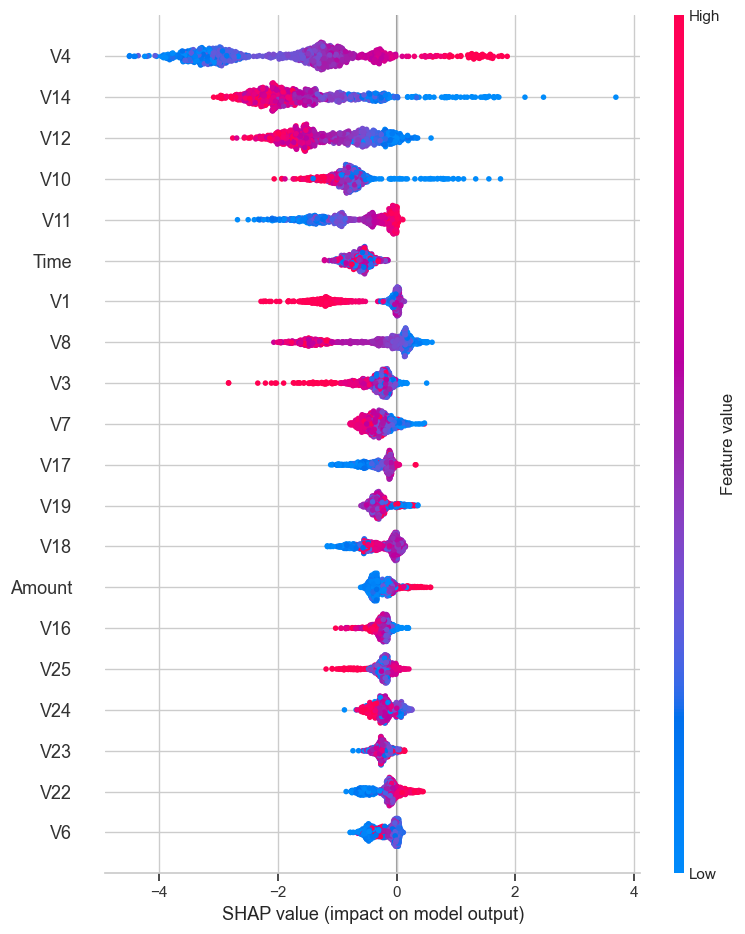

In [25]:
shap.summary_plot(shap_values, X_shap)

## SHAP FEATURE IMPORTANCE BAR PLOT

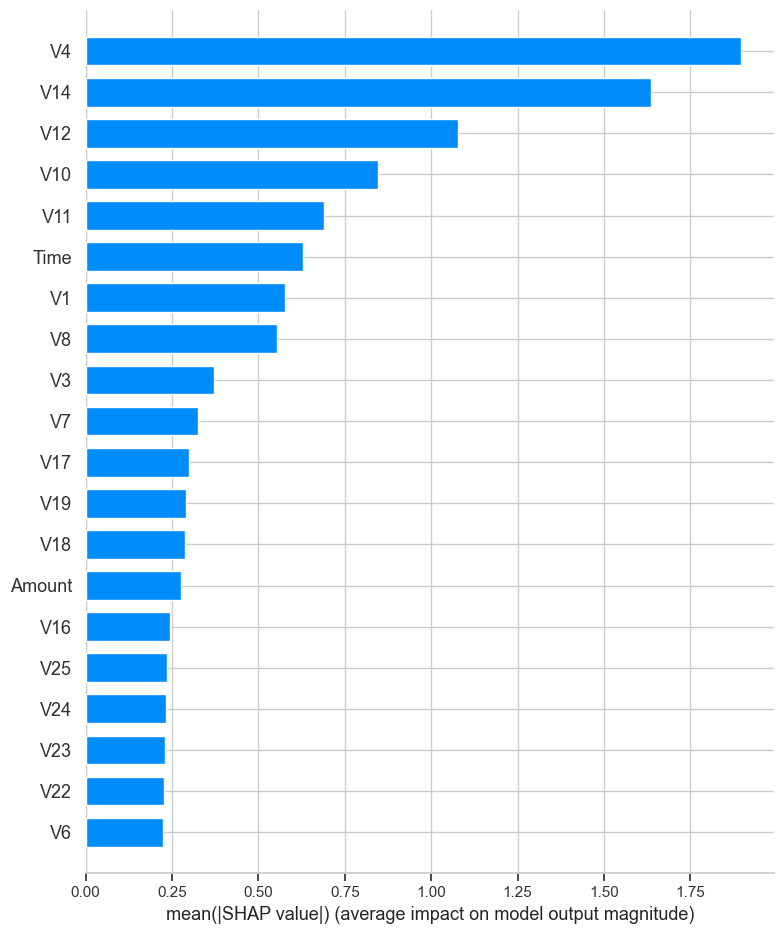

In [26]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

## SHAP LOCAL EXPLANATION FOR FRAUD CASE

Selected fraud transaction index in test set: 1867
True label: 1
Model fraud score: 0.999866


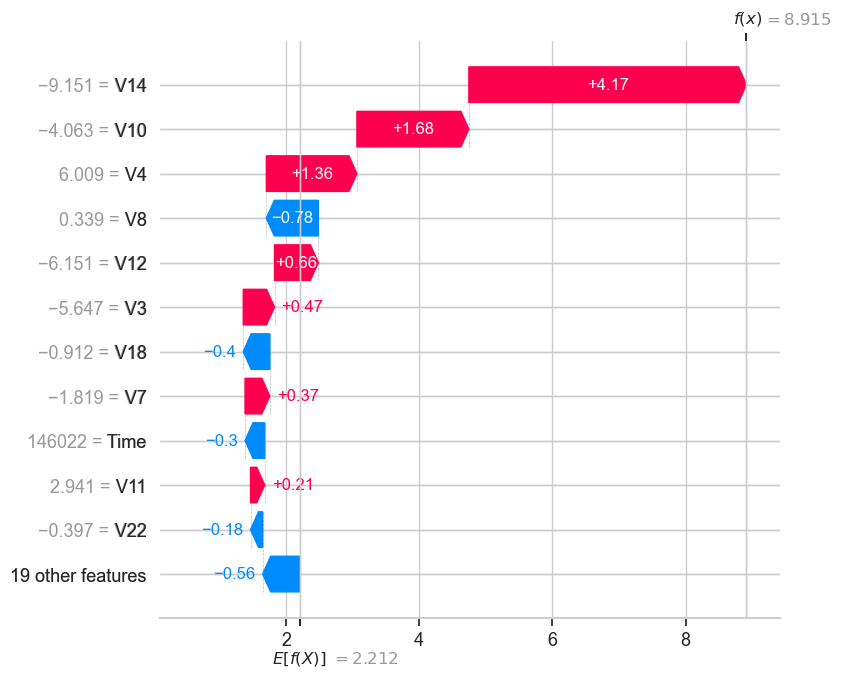

In [27]:
fraud_indices = np.where(y_test.values == 1)[0]

if len(fraud_indices) == 0:
    raise ValueError("No fraud cases found in test set.")

fraud_idx = int(fraud_indices[0])
X_local = X_test.iloc[[fraud_idx]]

local_score = get_model_scores(xai_model, X_local, xai_model_name)[0]

print("Selected fraud transaction index in test set:", fraud_idx)
print("True label:", int(y_test.iloc[fraud_idx]))
print("Model fraud score:", round(local_score, 6))

local_shap_values = shap_explainer.shap_values(X_local)

if isinstance(local_shap_values, list):
    local_shap_values = local_shap_values[1]

expected_value = shap_explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]

local_exp = shap.Explanation(
    values=local_shap_values[0],
    base_values=expected_value,
    data=X_local.iloc[0].values,
    feature_names=X_local.columns
)

shap.plots.waterfall(local_exp, max_display=12)

## TOP LOCAL SHAP FEATURES TABLE

In [28]:
local_shap_series = pd.Series(local_shap_values[0], index=X_test.columns)

top_local_shap = pd.DataFrame({
    "Feature": local_shap_series.abs().sort_values(ascending=False).head(10).index,
    "SHAP_Value": local_shap_series[local_shap_series.abs().sort_values(ascending=False).head(10).index].values,
    "Feature_Value": X_local.iloc[0][local_shap_series.abs().sort_values(ascending=False).head(10).index].values
})

display(top_local_shap)

,Feature,SHAP_Value,Feature_Value
0,V14,4.170050,-9.150951
1,V10,1.681450,-4.063098
2,V4,1.360516,6.009415
3,V8,-0.781398,0.338527
4,V12,0.658754,-6.151362
5,V3,0.469802,-5.647343
6,V18,-0.399584,-0.912058
7,V7,0.372765,-1.819308
8,Time,-0.295988,146022.000000
9,V11,0.213243,2.941190


## LIME EXPLAINER

In [29]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=["Legitimate", "Fraud"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

print("LIME explainer created.")

LIME explainer created.


## LIME LOCAL EXPLANATION

In [30]:
def operational_predict_proba(input_array):
    """
    Prediction function required by LIME.
    """
    input_df = pd.DataFrame(input_array, columns=X_train.columns)

    if operational_model_name == "Isolation Forest":
        scores = -operational_model.decision_function(input_df)
        scores_scaled = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        return np.column_stack([1 - scores_scaled, scores_scaled])

    return operational_model.predict_proba(input_df)


lime_exp = lime_explainer.explain_instance(
    data_row=X_local.iloc[0].values,
    predict_fn=operational_predict_proba,
    num_features=10
)

print("LIME explanation:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.6f}")

lime_exp.show_in_notebook(show_table=True)

LIME explanation:
V14 <= -0.37: 0.008553
V4 > 0.89: 0.008517
V12 <= -0.48: 0.006909
V3 <= -0.34: 0.006073
V10 <= -0.52: 0.004460
V21 > 0.15: 0.003904
V7 <= -0.58: 0.003470
V16 <= -0.48: 0.003421
Amount <= 5.99: 0.003026
V27 > 0.09: 0.002977


## PERMUTATION IMPORTANCE

,Feature,Importance_Mean,Importance_Std
14,V14,0.059366,0.034970
4,V4,0.042816,0.034692
23,V23,0.000225,0.000073
12,V12,0.000186,0.000080
3,V3,0.000172,0.000022
10,V10,0.000120,0.000047
17,V17,0.000101,0.000066
21,V21,0.000094,0.000060
22,V22,0.000082,0.000046
8,V8,0.000072,0.000149


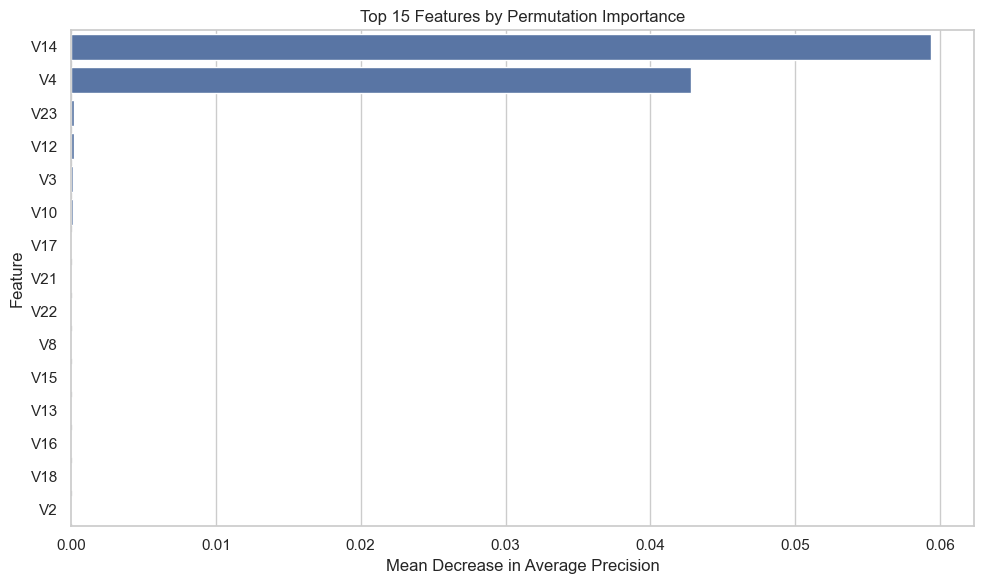

In [31]:
# Use a smaller sample for speed.
perm_sample_size = min(5000, len(X_test))
X_perm = X_test.sample(n=perm_sample_size, random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

if operational_model_name == "Isolation Forest":
    print("Permutation importance skipped for Isolation Forest operational model.")
else:
    perm_result = permutation_importance(
        operational_model,
        X_perm,
        y_perm,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        "Feature": X_perm.columns,
        "Importance_Mean": perm_result.importances_mean,
        "Importance_Std": perm_result.importances_std
    }).sort_values("Importance_Mean", ascending=False)

    display(perm_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=perm_df.head(15),
        x="Importance_Mean",
        y="Feature"
    )
    plt.title("Top 15 Features by Permutation Importance")
    plt.xlabel("Mean Decrease in Average Precision")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

## Multi-Agent Framework

## PREDICTION AGENT

In [32]:
class PredictionAgent:
    """
    Agent 1:
    Responsible for generating fraud probability or fraud risk score.
    """

    def __init__(self, model, model_name, feature_columns):
        self.model = model
        self.model_name = model_name
        self.feature_columns = feature_columns

    def score_transaction(self, transaction_dict):
        row = pd.DataFrame([transaction_dict], columns=self.feature_columns)
        score = get_model_scores(self.model, row, self.model_name)[0]

        return {
            "fraud_score": float(score),
            "transaction": transaction_dict
        }


prediction_agent = PredictionAgent(
    model=operational_model,
    model_name=operational_model_name,
    feature_columns=list(X_train.columns)
)

print("Prediction Agent initialized.")

Prediction Agent initialized.


## TRIAGE AGENT

In [33]:
class TriageAgent:
    """
    Agent 2:
    Converts fraud probability into risk level and recommended action.
    """

    def __init__(self, threshold):
        self.threshold = threshold

    def assess_risk(self, fraud_score):
        if fraud_score >= 0.95:
            return {
                "risk_level": "EXTREMELY HIGH",
                "action": "BLOCK IMMEDIATELY",
                "business_reason": "The model assigns near-certain fraud probability."
            }
        elif fraud_score >= 0.70:
            return {
                "risk_level": "HIGH",
                "action": "MANUAL REVIEW",
                "business_reason": "The transaction is highly suspicious and should be reviewed."
            }
        elif fraud_score >= self.threshold:
            return {
                "risk_level": "MEDIUM",
                "action": "STEP-UP AUTHENTICATION OR MONITOR",
                "business_reason": "The transaction exceeds the validation-optimized fraud threshold."
            }
        else:
            return {
                "risk_level": "LOW",
                "action": "APPROVE",
                "business_reason": "The transaction is below the operational alert threshold."
            }


triage_agent = TriageAgent(threshold=operational_threshold)

print("Triage Agent initialized.")

Triage Agent initialized.


## XAI EXPLANATION AGENT

In [34]:
class XAIExplanationAgent:
    """
    Agent 3:
    Generates model explanation using SHAP.
    """

    def __init__(self, shap_explainer, feature_columns):
        self.shap_explainer = shap_explainer
        self.feature_columns = feature_columns

    def explain_transaction(self, transaction_dict, top_k=6):
        row = pd.DataFrame([transaction_dict], columns=self.feature_columns)

        values = self.shap_explainer.shap_values(row)

        if isinstance(values, list):
            values = values[1]

        shap_series = pd.Series(values[0], index=self.feature_columns)

        top_features = shap_series.abs().sort_values(ascending=False).head(top_k).index

        explanation_df = pd.DataFrame({
            "Feature": top_features,
            "Feature_Value": row.iloc[0][top_features].values,
            "SHAP_Contribution": shap_series[top_features].values
        })

        explanation_df["Effect"] = np.where(
            explanation_df["SHAP_Contribution"] > 0,
            "Increases fraud risk",
            "Reduces fraud risk"
        )

        return explanation_df


xai_agent = XAIExplanationAgent(
    shap_explainer=shap_explainer,
    feature_columns=list(X_train.columns)
)

print("XAI Explanation Agent initialized.")

XAI Explanation Agent initialized.


## REPORT AGENT

In [35]:
class ReportAgent:
    """
    Agent 4:
    Converts prediction, triage, and XAI output into a readable fraud report.
    """

    def generate_report(self, prediction_output, triage_output, xai_output):
        fraud_score = prediction_output["fraud_score"]
        tx = prediction_output["transaction"]

        feature_lines = []

        for _, row in xai_output.iterrows():
            feature_lines.append(
                f"- {row['Feature']} = {row['Feature_Value']:.4f}: "
                f"{row['Effect']} "
                f"(SHAP contribution = {row['SHAP_Contribution']:.4f})"
            )

        report = f"""
# Real-Time Fraud Detection Report

## Model Output
- Fraud score: {fraud_score:.6f}
- Risk level: {triage_output['risk_level']}
- Recommended action: {triage_output['action']}

## Transaction Context
- Amount: {tx.get('Amount', 0):.2f}
- Time: {tx.get('Time', 0):.0f} seconds
- Approximate hour: {tx.get('Time', 0) // 3600:.0f}

## Business Rationale
{triage_output['business_reason']}

## Top Explainability Features
{chr(10).join(feature_lines)}

## Analyst Interpretation
The system combines a machine learning prediction agent, a business-rule triage agent, and an explainability agent. The prediction agent estimates fraud risk, the triage agent converts the score into an operational decision, and the XAI agent identifies the features most responsible for the model decision.
"""
        return report.strip()


report_agent = ReportAgent()

print("Report Agent initialized.")

Report Agent initialized.


## FULL MULTI-AGENT PIPELINE

In [36]:
def run_multi_agent_fraud_pipeline(transaction_dict):
    """
    Runs complete fraud detection workflow:
    1. Prediction Agent
    2. Triage Agent
    3. XAI Explanation Agent
    4. Report Agent
    """

    prediction_output = prediction_agent.score_transaction(transaction_dict)

    triage_output = triage_agent.assess_risk(
        prediction_output["fraud_score"]
    )

    xai_output = xai_agent.explain_transaction(
        transaction_dict,
        top_k=6
    )

    report = report_agent.generate_report(
        prediction_output,
        triage_output,
        xai_output
    )

    return {
        "prediction": prediction_output,
        "triage": triage_output,
        "xai": xai_output,
        "report": report
    }


print("Multi-agent fraud pipeline ready.")

Multi-agent fraud pipeline ready.


## MULTI-AGENT DEMO

In [37]:
fraud_transaction = X_test[y_test == 1].iloc[0].to_dict()
legitimate_transaction = X_test[y_test == 0].iloc[0].to_dict()

fraud_result = run_multi_agent_fraud_pipeline(fraud_transaction)
legit_result = run_multi_agent_fraud_pipeline(legitimate_transaction)

display(Markdown("## Real Fraud Transaction"))
display(Markdown(fraud_result["report"]))
display(fraud_result["xai"])

display(Markdown("---"))

display(Markdown("## Real Legitimate Transaction"))
display(Markdown(legit_result["report"]))
display(legit_result["xai"])

## Real Fraud Transaction

# Real-Time Fraud Detection Report

## Model Output
- Fraud score: 0.999866
- Risk level: EXTREMELY HIGH
- Recommended action: BLOCK IMMEDIATELY

## Transaction Context
- Amount: 1.18
- Time: 146022 seconds
- Approximate hour: 40

## Business Rationale
The model assigns near-certain fraud probability.

## Top Explainability Features
- V14 = -9.1510: Increases fraud risk (SHAP contribution = 4.1701)
- V10 = -4.0631: Increases fraud risk (SHAP contribution = 1.6815)
- V4 = 6.0094: Increases fraud risk (SHAP contribution = 1.3605)
- V8 = 0.3385: Reduces fraud risk (SHAP contribution = -0.7814)
- V12 = -6.1514: Increases fraud risk (SHAP contribution = 0.6588)
- V3 = -5.6473: Increases fraud risk (SHAP contribution = 0.4698)

## Analyst Interpretation
The system combines a machine learning prediction agent, a business-rule triage agent, and an explainability agent. The prediction agent estimates fraud risk, the triage agent converts the score into an operational decision, and the XAI agent identifies the features most responsible for the model decision.

,Feature,Feature_Value,SHAP_Contribution,Effect
0,V14,-9.150951,4.170050,Increases fraud risk
1,V10,-4.063098,1.681450,Increases fraud risk
2,V4,6.009415,1.360516,Increases fraud risk
3,V8,0.338527,-0.781398,Reduces fraud risk
4,V12,-6.151362,0.658754,Increases fraud risk
5,V3,-5.647343,0.469802,Increases fraud risk


---

## Real Legitimate Transaction

# Real-Time Fraud Detection Report

## Model Output
- Fraud score: 0.000053
- Risk level: LOW
- Recommended action: APPROVE

## Transaction Context
- Amount: 50.00
- Time: 145248 seconds
- Approximate hour: 40

## Business Rationale
The transaction is below the operational alert threshold.

## Top Explainability Features
- V14 = 0.0318: Reduces fraud risk (SHAP contribution = -1.9320)
- V1 = 1.9140: Reduces fraud risk (SHAP contribution = -1.2867)
- V11 = -0.8923: Reduces fraud risk (SHAP contribution = -1.1077)
- V4 = 0.6047: Reduces fraud risk (SHAP contribution = -0.8492)
- Time = 145248.0000: Reduces fraud risk (SHAP contribution = -0.7460)
- V10 = 0.0935: Reduces fraud risk (SHAP contribution = -0.7367)

## Analyst Interpretation
The system combines a machine learning prediction agent, a business-rule triage agent, and an explainability agent. The prediction agent estimates fraud risk, the triage agent converts the score into an operational decision, and the XAI agent identifies the features most responsible for the model decision.

,Feature,Feature_Value,SHAP_Contribution,Effect
0,V14,0.031774,-1.932021,Reduces fraud risk
1,V1,1.914027,-1.286726,Reduces fraud risk
2,V11,-0.892305,-1.107718,Reduces fraud risk
3,V4,0.604711,-0.849234,Reduces fraud risk
4,Time,145248.000000,-0.746005,Reduces fraud risk
5,V10,0.093484,-0.736747,Reduces fraud risk


## CONFIGURE GEMINI API KEY

In [38]:
from dotenv import load_dotenv
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

if GOOGLE_API_KEY:
    print("Google API key loaded from environment.")
else:
    print("GOOGLE_API_KEY not found.")
    print("Add it to a .env file or Colab Secrets before running Gemini cells.")

GOOGLE_API_KEY not found.
Add it to a .env file or Colab Secrets before running Gemini cells.


## GEMINI ANALYST AGENT

In [39]:
try:
    from google import genai
    GEMINI_AVAILABLE = True
except Exception as e:
    GEMINI_AVAILABLE = False
    print("Google GenAI SDK import failed:", e)


class GeminiAnalystAgent:
    """
    Optional Agent 5:
    Uses Gemini to rewrite technical ML/XAI output into a professional fraud analyst report.
    """

    def __init__(self, api_key, model_candidates=None):
        if not api_key:
            raise ValueError("GOOGLE_API_KEY is missing.")

        self.client = genai.Client(api_key=api_key)

        if model_candidates is None:
            self.model_candidates = [
                "gemini-2.5-flash",
                "gemini-2.0-flash",
                "gemini-1.5-flash"
            ]
        else:
            self.model_candidates = model_candidates

    def generate_analysis(self, report_text):
        prompt = f"""
You are a senior fraud operations analyst.

Rewrite the following model-generated fraud detection report into a concise,
professional, human-readable report for a banking fraud team.

Rules:
- Do not invent facts.
- Use only the provided model score, risk level, action, and XAI features.
- Explain why the transaction is suspicious or safe.
- End with a clear recommended action.

MODEL REPORT:
{report_text}
"""

        last_error = None

        for model_name in self.model_candidates:
            try:
                response = self.client.models.generate_content(
                    model=model_name,
                    contents=prompt
                )
                return {
                    "model_used": model_name,
                    "analysis": response.text
                }
            except Exception as e:
                last_error = e
                continue

        return {
            "model_used": None,
            "analysis": f"All Gemini models failed. Last error: {last_error}"
        }


if GEMINI_AVAILABLE and GOOGLE_API_KEY:
    gemini_agent = GeminiAnalystAgent(api_key=GOOGLE_API_KEY)
    print("Gemini Analyst Agent initialized.")
else:
    gemini_agent = None
    print("Gemini Analyst Agent not initialized.")

Gemini Analyst Agent not initialized.


## GEMINI FRAUD EXPLANATION

In [40]:
if gemini_agent is not None:
    gemini_output = gemini_agent.generate_analysis(fraud_result["report"])

    print("Gemini model used:", gemini_output["model_used"])
    display(Markdown(gemini_output["analysis"]))
else:
    print("Gemini agent not available. Use the offline XAI report instead.")

Gemini agent not available. Use the offline XAI report instead.


## ADK-COMPATIBLE FRAUD SCORING TOOL

In [41]:
def fraud_scoring_tool(
    Time: float,
    V1: float, V2: float, V3: float, V4: float, V5: float, V6: float, V7: float,
    V8: float, V9: float, V10: float, V11: float, V12: float, V13: float,
    V14: float, V15: float, V16: float, V17: float, V18: float, V19: float,
    V20: float, V21: float, V22: float, V23: float, V24: float, V25: float,
    V26: float, V27: float, V28: float,
    Amount: float
) -> str:
    """
    Scores a credit card transaction and returns fraud probability, risk level,
    recommended action, and key transaction details.
    """

    tx = {
        "Time": Time,
        "V1": V1, "V2": V2, "V3": V3, "V4": V4, "V5": V5, "V6": V6, "V7": V7,
        "V8": V8, "V9": V9, "V10": V10, "V11": V11, "V12": V12, "V13": V13,
        "V14": V14, "V15": V15, "V16": V16, "V17": V17, "V18": V18, "V19": V19,
        "V20": V20, "V21": V21, "V22": V22, "V23": V23, "V24": V24, "V25": V25,
        "V26": V26, "V27": V27, "V28": V28,
        "Amount": Amount
    }

    result = run_multi_agent_fraud_pipeline(tx)

    return result["report"]


print("ADK-compatible fraud scoring tool is ready.")

ADK-compatible fraud scoring tool is ready.


## OPTIONAL GOOGLE ADK LLM AGENT SETUP

In [42]:
try:
    from google.adk.agents import LlmAgent
    from google.adk.models.google_llm import Gemini
    ADK_AVAILABLE = True
except Exception as e:
    ADK_AVAILABLE = False
    print("ADK import failed:", e)


if ADK_AVAILABLE:
    fraud_adk_agent = LlmAgent(
        name="fraud_detection_explanation_agent",
        model=Gemini(model="gemini-2.5-flash"),
        description="Explains credit card fraud detection decisions using a trained ML model and XAI report.",
        instruction="""
You are a senior fraud detection analyst.

When given a transaction, use the fraud_scoring_tool first.
Then explain:
1. fraud probability,
2. risk level,
3. recommended action,
4. main XAI indicators,
5. final analyst recommendation.

Do not invent facts beyond the tool output.
""",
        tools=[fraud_scoring_tool]
    )

    print("Google ADK fraud agent created.")
else:
    fraud_adk_agent = None
    print("ADK agent was not created.")

ADK import failed: No module named 'google.adk'
ADK agent was not created.


## FINAL THESIS SUMMARY

In [43]:
best_row = results_df.iloc[0]

summary_text = f"""
# Final Experimental Summary

## Best Experimental Model
The best model based on validation PR-AUC was **{best_row['Model']}**.

## Operational Model
The operational model selected for the real-time multi-agent framework was **{operational_model_name}**.

## Test Performance of Operational Model
- ROC-AUC: {results_df[results_df['Model'] == operational_model_name]['Test_ROC_AUC'].values[0]:.4f}
- PR-AUC: {results_df[results_df['Model'] == operational_model_name]['Test_PR_AUC'].values[0]:.4f}
- Precision: {results_df[results_df['Model'] == operational_model_name]['Test_Precision'].values[0]:.4f}
- Recall: {results_df[results_df['Model'] == operational_model_name]['Test_Recall'].values[0]:.4f}
- F1-score: {results_df[results_df['Model'] == operational_model_name]['Test_F1'].values[0]:.4f}

## Novel Contribution
This project is not limited to building an XGBoost fraud classifier.

The novelty is the integrated framework that combines:

1. comparative evaluation of multiple fraud detection algorithms,
2. threshold optimization under severe class imbalance,
3. SHAP-based global and local explainability,
4. LIME and permutation importance as additional model-agnostic XAI methods,
5. a multi-agent fraud decision architecture,
6. optional Gemini-based analyst explanation generation.

This makes the system more suitable for real-time fraud operations because it provides not only a prediction, but also a risk category, recommended action, and human-readable explanation.
"""

display(Markdown(summary_text))


# Final Experimental Summary

## Best Experimental Model
The best model based on validation PR-AUC was **XGBoost**.

## Operational Model
The operational model selected for the real-time multi-agent framework was **XGBoost**.

## Test Performance of Operational Model
- ROC-AUC: 0.9872
- PR-AUC: 0.7942
- Precision: 0.8615
- Recall: 0.7467
- F1-score: 0.8000

## Novel Contribution
This project is not limited to building an XGBoost fraud classifier.

The novelty is the integrated framework that combines:

1. comparative evaluation of multiple fraud detection algorithms,
2. threshold optimization under severe class imbalance,
3. SHAP-based global and local explainability,
4. LIME and permutation importance as additional model-agnostic XAI methods,
5. a multi-agent fraud decision architecture,
6. optional Gemini-based analyst explanation generation.

This makes the system more suitable for real-time fraud operations because it provides not only a prediction, but also a risk category, recommended action, and human-readable explanation.


## EXPORT RESULTS

In [44]:
results_df.to_csv(OUTPUT_DIR / "full_model_results.csv", index=False)

with open(OUTPUT_DIR / "final_thesis_summary.md", "w", encoding="utf-8") as f:
    f.write(summary_text)

with open(OUTPUT_DIR / "sample_fraud_report.md", "w", encoding="utf-8") as f:
    f.write(fraud_result["report"])

print("Saved:")
print("- outputs/full_model_results.csv")
print("- outputs/final_thesis_summary.md")
print("- outputs/sample_fraud_report.md")

Saved:
- outputs/full_model_results.csv
- outputs/final_thesis_summary.md
- outputs/sample_fraud_report.md
